<div style="background-color: #333; padding: 40px; border: 2px solid #ffd700; border-radius: 10px; color: #ffd700; text-align: center; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2);">

<h1 style="font-size: 48px; font-weight: bold; color: #ffd700;">LLM Classification finetuning ELECTRA</h1>

<img src="https://cdn.arstechnica.net/wp-content/uploads/2023/12/GettyImages-152404829-scaled.jpg" alt="Chatbot arena" style="width: 500px; margin: 20px auto; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2);">
    
</div>

## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">Table of content</div>

<ul class="list-group" id="list-tab" role="tablist">
    <li><a href="#0.-Introduction">0. Introduction</a></li><br>
    <li><a href="#1.-Import-Libraries">1. Import Libraries</a></li><br>
    <li><a href="#2.-Data-Loading-&-Inspection">2. Data Loading & Inspection</a></li><br>
    <li><a href="#3.-Text-Preprocessing">3. Text Preprocessing</a></li><br>
    <li><a href="#4.-Dataset-Preparation">4. Dataset Preparation</a></li><br>
    <li><a href="#5.-Model-Building">5. Model Building</a></li><br>
    <li><a href="#6.-Training-&-Evaluation">6. Training & Evaluation</a></li><br>
    <li><a href="#7.-Prediction-&-Submission">7. Prediction & Submission</a></li><br>
</ul>

## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">0. Introduction</div>

### Intro : 

In the rapidly evolving world of large language models (LLMs), one of the most critical challenges is ensuring that AI-generated responses align with human preferences. While modern chatbots can produce fluent and coherent text, not all responses are equally engaging, helpful, or satisfying to users. This Kaggle competition tackles this challenge head-on by leveraging real-world data from Chatbot Arena, where users compare responses from different LLMs and choose their preferred one.

### Competition Overview :

The goal is to predict which LLM response a human judge will prefer in a head-to-head battle. Each conversation consists of:

A user prompt (the input given to the chatbots).

Two LLM-generated responses (anonymous models competing against each other).

A human preference label (indicating which response was preferred).

This task mirrors Reinforcement Learning from Human Feedback (RLHF), a key technique for aligning AI with human values. Successfully predicting preferences helps improve reward models, which are essential for training better chatbots.

### Key challenges :

1. Biases in Human Judgments

    * Position bias: Users may favor the first or second response due to ordering.

    * Verbosity bias: Longer responses might be preferred even if less accurate.

    * Self-enhancement bias: Models may subtly promote themselves.

2. Model Generalization

    * The test set (~25K samples) requires robust predictions beyond the training data (55K samples).

3. Interpretable Preference Modeling

    * Understanding why users prefer certain responses can guide better LLM fine-tuning.
  
### Why this matters :

Improving preference prediction models directly enhances:

* Chatbot training.

* User satisfaction (by aligning AI with human expectations).

* Fairness & robustness (reducing biases in AI judgments).

By competing in this challenge, we contribute to the future of human-aligned AI assistants—making them not just smarter, but also more attuned to what users truly want.

## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">1. Import Libraries</div>

In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.gpu_device_name())

# Configure GPU memory growth (prevents OOM errors)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

2026-05-11 03:40:20.086362: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778470820.285478      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778470820.341480      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778470820.826884      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778470820.826928      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778470820.826931      22 computation_placer.cc:177] computation placer alr

Num GPUs Available:  1
/device:GPU:0


I0000 00:00:1778470846.244752      22 gpu_device.cc:2019] Created device /device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import keras_nlp
from sklearn.model_selection import train_test_split
from keras import backend as K

# Configuration
# ELECTRA-large: ~335M params, hidden size 1024, 24 layers.
# If you hit OOM on a P100/T4, drop to "electra_base_en" (~110M, hidden 768)
# and you can probably push BATCH_SIZE back up to 16.
MODEL_NAME = "electra_large_discriminator_uncased_en"
SEQUENCE_LENGTH = 256
BATCH_SIZE = 8          # large model + Siamese (2 passes) is memory-heavy
EPOCHS = 10
LEARNING_RATE = 1e-5    # ELECTRA-large prefers a slightly lower LR than base-sized models


## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">2. Data Loading & Inspection</div>

In [3]:
# Load datasets
train_df = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/test.csv")

# Quick inspection
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (57477, 9)
Test shape: (3, 4)


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


In [4]:
# Basic validation checks
def check_data(df, name):
    print(f"\n{name} Data Summary:")
    print("- Missing values:", df.isna().sum().sum())
    print("- Duplicates:", df.duplicated().sum())
    print("- Target distribution:")
    print(df[['winner_model_a', 'winner_model_b', 'winner_tie']].mean())


check_data(train_df, "Train")


Train Data Summary:
- Missing values: 0
- Duplicates: 0
- Target distribution:
winner_model_a    0.349079
winner_model_b    0.341911
winner_tie        0.309011
dtype: float64


## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">3. Text Preprocessing</div>

In [5]:
class TextPreprocessor:
    def __init__(self):
        pass  # tokenization happens later, in the dataset pipeline

    def clean_text(self, text):
        """Light text normalization"""
        text = str(text)
        text = re.sub(r"\s+", " ", text)             # Collapse whitespace
        text = re.sub(r"[^\x00-\x7F]+", " ", text)  # Remove non-ASCII (English-only model)
        return text.strip()

    def create_input_pairs(self, row):
        """Return [(prompt, response_a), (prompt, response_b)] — each becomes a two-segment input"""
        clean_prompt = self.clean_text(row['prompt'])
        return [
            (clean_prompt, self.clean_text(row['response_a'])),
            (clean_prompt, self.clean_text(row['response_b'])),
        ]

# Initialize processor
processor = TextPreprocessor()


In [6]:
# Apply preprocessing
train_df['inputs'] = train_df.apply(processor.create_input_pairs, axis=1)
test_df['inputs'] = test_df.apply(processor.create_input_pairs, axis=1)

# Create labels (0: model_a wins, 1: model_b wins, 2: tie)
train_df['label'] = train_df[['winner_model_a', 'winner_model_b', 'winner_tie']].idxmax(axis=1)
train_df['label'] = train_df['label'].map({'winner_model_a':0, 'winner_model_b':1, 'winner_tie':2})

# Preview processed data
train_df[['inputs', 'label']].head()

,inputs,label
0,"[([""Is it morally right to try to have a certa...",0
1,"[([""What is the difference between marriage li...",1
2,"[([""explain function calling. how would you ca...",2
3,"[([""How can I create a test set for a very rar...",0
4,"[([""What is the best way to travel from Tel-Av...",1


## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">4. Dataset Preparation</div>

In [7]:
# Train/validation split
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['label'],
    random_state=42
)

# ELECTRA does not ship an ElectraPreprocessor preset in keras_hub,
tokenizer = keras_nlp.models.ElectraTokenizer.from_preset(MODEL_NAME)
# Cache the special token IDs as Python ints
CLS_ID = int(tokenizer.cls_token_id)
SEP_ID = int(tokenizer.sep_token_id)
PAD_ID = int(tokenizer.pad_token_id)

def electra_preprocess(prompt, response):
    """(prompt, response) -> {token_ids, padding_mask, segment_ids} in ELECTRA format.

    Layout: [CLS] prompt_tokens [SEP] response_tokens [SEP]  (padded to SEQUENCE_LENGTH)
    segment_ids: 0 for [CLS] + prompt + first [SEP], 1 for response + final [SEP].
    """
    prompt_tokens = tokenizer(prompt)
    response_tokens = tokenizer(response)

    # Reserve 3 slots for [CLS] ... [SEP] ... [SEP]. Split the rest between prompt and response.
    budget = SEQUENCE_LENGTH - 3
    half = budget // 2
    prompt_tokens = prompt_tokens[:half]
    response_tokens = response_tokens[: budget - tf.shape(prompt_tokens)[0]]

    # Build the segments
    cls = tf.constant([CLS_ID], dtype=prompt_tokens.dtype)
    sep = tf.constant([SEP_ID], dtype=prompt_tokens.dtype)
    seg_a = tf.concat([cls, prompt_tokens, sep], axis=0)         # segment 0
    seg_b = tf.concat([response_tokens, sep], axis=0)            # segment 1

    token_ids = tf.concat([seg_a, seg_b], axis=0)
    segment_ids = tf.concat(
        [tf.zeros_like(seg_a), tf.ones_like(seg_b)], axis=0
    )

    # Pad (or truncate as a safety net) to SEQUENCE_LENGTH
    cur_len = tf.shape(token_ids)[0]
    pad_len = SEQUENCE_LENGTH - cur_len
    token_ids = tf.pad(token_ids, [[0, pad_len]], constant_values=PAD_ID)
    segment_ids = tf.pad(segment_ids, [[0, pad_len]], constant_values=0)

    token_ids.set_shape([SEQUENCE_LENGTH])
    segment_ids.set_shape([SEQUENCE_LENGTH])

    padding_mask = tf.cast(token_ids != PAD_ID, tf.int32)
    return {
        "token_ids": token_ids,
        "padding_mask": padding_mask,
        "segment_ids": segment_ids,
    }

def create_dataset(text_pairs, labels=None):
    """text_pairs is a list of [(prompt, resp_a), (prompt, resp_b)] entries."""
    AUTO = tf.data.AUTOTUNE

    # Unpack into four parallel string tensors so tf.data can handle them.
    prompts_a = [pair[0][0] for pair in text_pairs]
    responses_a = [pair[0][1] for pair in text_pairs]
    prompts_b = [pair[1][0] for pair in text_pairs]
    responses_b = [pair[1][1] for pair in text_pairs]

    if labels is not None:
        ds = tf.data.Dataset.from_tensor_slices(
            ((prompts_a, responses_a, prompts_b, responses_b), labels)
        )
        ds = ds.shuffle(1000)
    else:
        ds = tf.data.Dataset.from_tensor_slices(
            (prompts_a, responses_a, prompts_b, responses_b)
        )

    def preprocess_pair(*args):
        """Tokenize both (prompt, response) pairs and stack into (2, seq_len) tensors"""
        if len(args) == 2:
            (p_a, r_a, p_b, r_b), label = args
        else:
            (p_a, r_a, p_b, r_b) = args
            label = None

        processed_a = electra_preprocess(p_a, r_a)
        processed_b = electra_preprocess(p_b, r_b)

        model_inputs = {
            "token_ids":    tf.stack([processed_a["token_ids"],    processed_b["token_ids"]],    axis=0),
            "padding_mask": tf.stack([processed_a["padding_mask"], processed_b["padding_mask"]], axis=0),
            "segment_ids":  tf.stack([processed_a["segment_ids"],  processed_b["segment_ids"]],  axis=0),
        }
        return (model_inputs, label) if label is not None else model_inputs

    ds = ds.map(preprocess_pair, num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTO)
    return ds

# Prepare all datasets
train_ds = create_dataset(
    train_df['inputs'].tolist(),
    tf.keras.utils.to_categorical(train_df['label']),
)
valid_ds = create_dataset(
    valid_df['inputs'].tolist(),
    tf.keras.utils.to_categorical(valid_df['label']),
)
test_ds = create_dataset(
    test_df['inputs'].tolist(),
)


I0000 00:00:1778470866.421463      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
# Check a batch from your dataset
for batch in train_ds.take(1):
    inputs, labels = batch
    print("Token IDs shape:   ", inputs["token_ids"].shape)     # (batch_size, 2, 256)
    print("Padding mask shape:", inputs["padding_mask"].shape)
    print("Segment IDs shape: ", inputs["segment_ids"].shape)
    print("Example token_ids[0,0,:5]:", inputs["token_ids"][0,0,:5].numpy())


Token IDs shape:    (8, 2, 256)
Padding mask shape: (8, 2, 256)
Segment IDs shape:  (8, 2, 256)
Example token_ids[0,0,:5]: [ 101 1031 1000 2129 2000]


## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">5. Model Building</div>

In [9]:
def build_electra_classifier():
    # Input layers — three streams now, ELECTRA uses segment_ids too
    token_ids = tf.keras.layers.Input(
        shape=(2, SEQUENCE_LENGTH), dtype="int32", name="token_ids"
    )
    padding_mask = tf.keras.layers.Input(
        shape=(2, SEQUENCE_LENGTH), dtype="int32", name="padding_mask"
    )
    segment_ids = tf.keras.layers.Input(
        shape=(2, SEQUENCE_LENGTH), dtype="int32", name="segment_ids"
    )

    inputs = {
        "token_ids": token_ids,
        "padding_mask": padding_mask,
        "segment_ids": segment_ids,
    }

    # Shared ELECTRA backbone (Siamese)
    backbone = keras_nlp.models.ElectraBackbone.from_preset(MODEL_NAME)

    # Slice the (B, 2, T) inputs into two (B, T) streams per response
    def slice_index(x, index):
        return tf.keras.layers.Lambda(
            lambda t: t[:, index, :],
            output_shape=(SEQUENCE_LENGTH,),
        )(x)

    ids_a, ids_b = slice_index(token_ids, 0), slice_index(token_ids, 1)
    mask_a, mask_b = slice_index(padding_mask, 0), slice_index(padding_mask, 1)
    seg_a, seg_b = slice_index(segment_ids, 0), slice_index(segment_ids, 1)

    emb_a = backbone({
        "token_ids": ids_a,
        "padding_mask": mask_a,
        "segment_ids": seg_a,
    })["sequence_output"]   # (B, T, 1024)
    emb_b = backbone({
        "token_ids": ids_b,
        "padding_mask": mask_b,
        "segment_ids": seg_b,
    })["sequence_output"]

    # Masked mean pooling, written with keras.ops so it works on KerasTensors
    class MaskedMeanPool(tf.keras.layers.Layer):
        def call(self, seq, mask):
            mask_f = keras.ops.cast(mask, seq.dtype)
            mask_f = keras.ops.expand_dims(mask_f, axis=-1)         # (B, T, 1)
            summed = keras.ops.sum(seq * mask_f, axis=1)            # (B, H)
            denom = keras.ops.sum(mask_f, axis=1) + 1e-6            # (B, 1)
            return summed / denom

    pool = MaskedMeanPool()
    pooled_a = pool(emb_a, mask_a)
    pooled_b = pool(emb_b, mask_b)

    # Comparison fusion: [a, b, a-b, a*b]
    diff = tf.keras.layers.Subtract()([pooled_a, pooled_b])
    prod = tf.keras.layers.Multiply()([pooled_a, pooled_b])
    fused = tf.keras.layers.Concatenate()([pooled_a, pooled_b, diff, prod])  # (B, 4H)

    x = tf.keras.layers.Dropout(0.3)(fused)
    x = tf.keras.layers.Dense(256, activation="gelu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Build and compile
model = build_electra_classifier()

model.compile(
    optimizer=tf.keras.optimizers.AdamW(LEARNING_RATE, weight_decay=0.01),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", "categorical_crossentropy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ padding_mask        │ (None, 2, 256)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, 2, 256)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, 2, 256)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 256)       │          0 │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 256)       │          0 │ segment_ids[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256)       │          0 │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 256)       │          0 │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 256)       │          0 │ segment_ids[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 256)       │          0 │ token_ids[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ electra_backbone    │ [(None, 1024),    │ 335,141,8… │ lambda_2[0][0],   │
│ (ElectraBackbone)   │ (None, 256,       │            │ lambda_4[0][0],   │
│                     │ 1024)]            │            │ lambda[0][0],     │
│                     │                   │            │ lambda_3[0][0],   │
│                     │                   │            │ lambda_5[0][0],   │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean_pool    │ (None, 1024)      │          0 │ electra_backbone… │
│ (MaskedMeanPool)    │                   │            │ lambda_2[0][0],   │
│                     │                   │            │ electra_backbone… │
│                     │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 1024)      │          0 │ masked_mean_pool… │
│                     │                   │            │ masked_mean_pool… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1024)      │          0 │ masked_mean_pool… │
│                     │                   │            │ masked_mean_pool… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4096)      │          0 │ masked_mean_pool… │
│ (Concatenate)       │                   │            │ masked_mean_pool… │
│                     │                   │            │ subtract[0][0],   │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 4096)      │          0 │ concatenate[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 336,191,491 (1.25 GB)

 Trainable params: 336,191,491 (1.25 GB)

 Non-trainable params: 0 (0.00 B)

## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">6. Training & Evaluation</div>

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['pooled_dense/kernel', 'pooled_dense/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
I0000 00:00:1778470975.936843      64 service.cc:152] XLA service 0x7e27dc048940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778470975.936895      64 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778470992.655949      64 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778471116.989704      64 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6467/6467 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3373 - categorical_crossentropy: 1.1420 - loss: 1.1420

6467/6467 ━━━━━━━━━━━━━━━━━━━━ 8524s 1s/step - accuracy: 0.3373 - categorical_crossentropy: 1.1420 - loss: 1.1420 - val_accuracy: 0.3492 - val_categorical_crossentropy: 1.0989 - val_loss: 1.0994 - learning_rate: 1.0000e-05
Epoch 2/10
6467/6467 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3393 - categorical_crossentropy: 1.1027 - loss: 1.1029

6467/6467 ━━━━━━━━━━━━━━━━━━━━ 8158s 1s/step - accuracy: 0.3393 - categorical_crossentropy: 1.1027 - loss: 1.1029 - val_accuracy: 0.3492 - val_categorical_crossentropy: 1.0974 - val_loss: 1.0978 - learning_rate: 1.0000e-05
Epoch 3/10
6467/6467 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3366 - categorical_crossentropy: 1.1023 - loss: 1.1024

6467/6467 ━━━━━━━━━━━━━━━━━━━━ 8158s 1s/step - accuracy: 0.3366 - categorical_crossentropy: 1.1023 - loss: 1.1024 - val_accuracy: 0.3492 - val_categorical_crossentropy: 1.0974 - val_loss: 1.0976 - learning_rate: 1.0000e-05
Epoch 4/10
6467/6467 ━━━━━━━━━━━━━━━━━━━━ 8147s 1s/step - accuracy: 0.3394 - categorical_crossentropy: 1.1011 - loss: 1.1013 - val_accuracy: 0.3492 - val_categorical_crossentropy: 1.0977 - val_loss: 1.0981 - learning_rate: 1.0000e-05
Epoch 5/10
6467/6467 ━━━━━━━━━━━━━━━━━━━━ 8148s 1s/step - accuracy: 0.3627 - categorical_crossentropy: 1.0968 - loss: 1.0976 - val_accuracy: 0.3492 - val_categorical_crossentropy: 1.0981 - val_loss: 1.0981 - learning_rate: 5.0000e-06


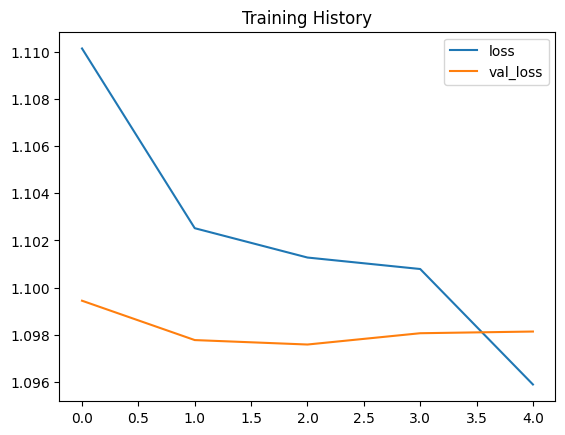

In [10]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.weights.h5", save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1)
]

# Train model
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Plot training history
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title("Training History")
plt.show()

## <div style="border-radius: 10px; border: 2px solid #ffd700; padding: 15px; background-color: #333; font-size: 120%; text-align: center; color: #ffd700; font-weight: bold;">7. Prediction & Submission</div>

In [11]:
# Generate predictions
test_preds = model.predict(test_ds)
test_df['prediction'] = np.argmax(test_preds, axis=1)

# Create submission
submission = pd.DataFrame({
            "id": test_df.id,
            "winner_model_a": test_preds[:, 0],
            "winner_model_b": test_preds[:, 1],
            "winner_tie": test_preds[:, 2]
        })
submission.to_csv("submission.csv", index=False)
print("Submission saved!")
submission

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Submission saved!


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.348896,0.334834,0.31627
1,211333,0.348896,0.334834,0.31627
2,1233961,0.348896,0.334834,0.31627
